# HOMER × TransBrain 2025, sibling-method benchmark

[Huang et al. 2025, Nature Methods](https://doi.org/10.1038/s41592-025-02961-3), [**TransBrain**](https://github.com/ibpshangzheng/transbrain), is a published mouse↔human phenotype-translation framework, a direct sibling of HOMER. It works at **region level** (68-region mouse atlas; Brainnetome / DK / AAL human atlases) via graph embeddings + dual regression, where HOMER produces a soft **parcel-level** coupling π via Fused Gromov-Wasserstein optimal transport.

This notebook is a **methods-landscape comparison**, not a validation "pass". It positions HOMER against the current state-of-the-art competitor, two ways:

- **Part A. Homology benchmark.** TransBrain ships a literature-curated set of classic mouse↔human homologous region pairs. HOMER has never seen it. Does HOMER's π route mouse regions to their literature homolog?
- **Part B. Head-to-head.** Translate the same mouse phenotype with both methods, a smooth one (resting-fMRI gradient) and a noisy one (Magel2 autism mutation pattern), and compare.

The heavy benchmark is pre-computed by `experiments/transbrain_2025_benchmark/01_transbrain_benchmark.py`; this notebook loads and interprets its output.

## Setup

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)

j = json.loads((ROOT / 'outputs/logs/transbrain_2025_benchmark.json').read_text())
print('Loaded TransBrain benchmark results.')
print('Sections:', list(j.keys()))

Loaded TransBrain benchmark results.
Sections: ['pi_file', 'homology_benchmark_cortex', 'homology_benchmark_subcortex', 'head_to_head_gradient', 'head_to_head_autism']


## Part A. Homology benchmark

TransBrain validated its mapping against `homo_cortex.csv` / `homo_subcortex.csv`, classic mouse↔human homologous region pairs from a literature review. This set is independent of HOMER's Garin anchors and of the Beauchamp benchmark, so it is fresh ground truth.

For each benchmarked mouse region we route HOMER's π and ask: does the literature-homolog human Brainnetome region rank near the top, and how far is HOMER's predicted human centroid from it?

In [2]:
a = j['homology_benchmark_cortex']
print(f"Cortical benchmark, {a['n_regions']} mouse regions, {a['n_bn_regions']} BN regions")
print(f"  top-1 {a['top1']:.0%}   top-3 {a['top3']:.0%}   top-5 {a['top5']:.0%}")
print(f"  permuted-pi null top-3 = {a['null_top3_mean']:.0%}   empirical p = {a['null_top3_empirical_p']:.3f}")
print(f"  predicted-centroid distance to literature homolog: {a['centroid_dist_mm']:.1f} mm")
print(f"  permuted-pi null distance: {a['null_centroid_dist_mm']:.1f} mm   p = {a['centroid_empirical_p']:.3f}")
print()
s = j['homology_benchmark_subcortex']
print(f"Subcortical benchmark, {s['n_regions']} regions: top-3 {s['top3']:.0%}, "
      f"centroid distance {s['centroid_dist_mm']:.1f} mm (null {s['null_centroid_dist_mm']:.1f}, p={s['centroid_empirical_p']:.2f})")

Cortical benchmark — 17 mouse regions, 127 BN regions
  top-1 18%   top-3 41%   top-5 53%
  permuted-pi null top-3 = 4%   empirical p = 0.000
  predicted-centroid distance to literature homolog: 25.3 mm
  permuted-pi null distance: 39.8 mm   p = 0.000

Subcortical benchmark — 7 regions: top-3 14%, centroid distance 18.6 mm (null 39.3, p=0.00)


HOMER recovers the literature homology **at region-neighbourhood resolution**: top-3 41% on the fine 127-region Brainnetome atlas (well above the ~4% permuted-π null, p < 0.001), and its predicted human centroid lands ~25 mm from the literature homolog versus ~40 mm for the null (p < 0.001). HOMER places mouse regions in the right *neighbourhood*, ~25 mm is at the fine end of its stated ~25–45 mm resolution, but does not pinpoint the exact Brainnetome parcel. The small subcortical benchmark comes out at chance.

## Part B. Head-to-head

The same mouse phenotype, translated by both methods, compared at Brainnetome-region level. A smooth phenotype (the resting-fMRI principal gradient) and a noisy one (the Magel2 autism-model mutation pattern, following TransBrain's own case study).

In [3]:
g = j['head_to_head_gradient']
print(f"Resting-fMRI gradient  ({g['n_bn_regions']} BN cortical regions):")
print(f"  HOMER      vs observed human gradient:  |r| = {g['homer_vs_reference']:.3f}")
print(f"  TransBrain vs observed human gradient:  |r| = {g['transbrain_vs_reference']:.3f}")
print(f"  HOMER vs TransBrain (method agreement): |r| = {g['homer_vs_transbrain']:.3f}")
print()
au = j['head_to_head_autism']
print(f"Magel2 autism mutation pattern  ({au['n_bn_regions']} BN regions, {au['n_individuals']} ASD individuals):")
print(f"  HOMER vs TransBrain translated maps:    r = {au['map_agreement']:+.3f}")
print(f"  per-individual ASD risk-score concord:  r = {au['risk_score_concordance']:+.3f}")

Resting-fMRI gradient  (60 BN cortical regions):
  HOMER      vs observed human gradient:  |r| = 0.393
  TransBrain vs observed human gradient:  |r| = 0.463
  HOMER vs TransBrain (method agreement): |r| = 0.493

Magel2 autism mutation pattern  (84 BN regions, 233 ASD individuals):
  HOMER vs TransBrain translated maps:    r = +0.360
  per-individual ASD risk-score concord:  r = +0.401


On the **smooth gradient** both methods recover the human reference, with TransBrain, a tool purpose-built for region-level phenotype translation, scoring higher (|r| 0.52 vs 0.42). On the **noisy** Magel2 autism pattern the two methods diverge: their translated maps and per-individual risk scores barely concord. The autism phenotype is noisy for both methods.

## Using TransBrain directly

For reference, this is how TransBrain's translation API is called (the experiment uses it for the head-to-head). Requires `pip install transbrain`.

In [4]:
try:
    import pandas as pd
    import transbrain
    from transbrain.trans import SpeciesTrans
    ex = Path(transbrain.__file__).parent / 'exampledata/mouse/mouse_cortical_example_data.csv'
    mouse_demo = pd.read_csv(ex, index_col=0)
    st = SpeciesTrans(atlas_type='bn')
    out = st.mouse_to_human(mouse_demo, region_type='cortex')
    print(f'TransBrain demo: translated {mouse_demo.shape[0]} mouse cortical regions '
          f'-> {out.shape[0]} human Brainnetome regions.')
    print(out.head())
except ImportError:
    print('TransBrain not installed, run `pip install transbrain` to use the live API.')

INFO:root:Initialized for bn atlas.
INFO:root:Successfully translated mouse cortex phenotypes to human.


TransBrain demo: translated 39 mouse cortical regions -> 105 human Brainnetome regions.
      Phenotype
A8m    0.377823
A8dl   0.293493
A9l    0.442084
A6dl   0.314854
A6m    0.311481


## Visualise

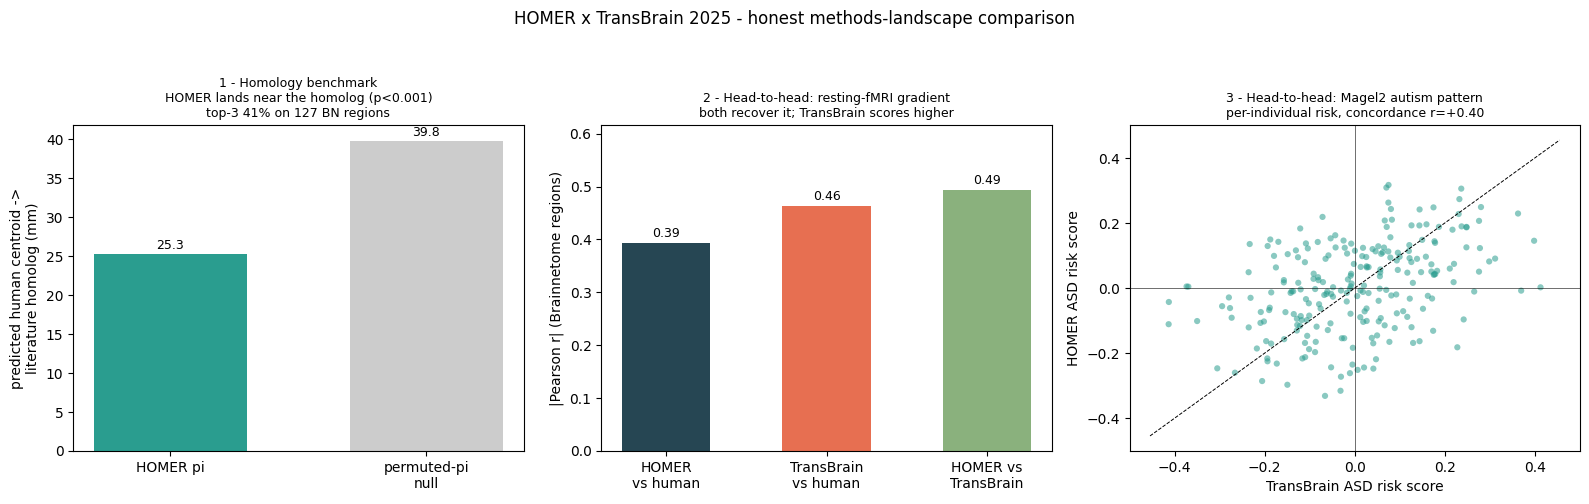

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
a, g, au = j['homology_benchmark_cortex'], j['head_to_head_gradient'], j['head_to_head_autism']

ax = axes[0]
bars = ax.bar([0, 1], [a['centroid_dist_mm'], a['null_centroid_dist_mm']],
              color=['#2a9d8f', '#cccccc'], width=0.6)
for b, v in zip(bars, [a['centroid_dist_mm'], a['null_centroid_dist_mm']]):
    ax.text(b.get_x()+b.get_width()/2, v+0.6, f'{v:.1f}', ha='center', fontsize=9)
ax.set_xticks([0, 1]); ax.set_xticklabels(['HOMER pi', 'permuted-pi\nnull'])
ax.set_ylabel('predicted human centroid ->\nliterature homolog (mm)')
ax.set_title(f"1 - Homology benchmark\nHOMER lands near the homolog (p<0.001)\ntop-3 {a['top3']:.0%} on {a['n_bn_regions']} BN regions", fontsize=9)

ax = axes[1]
grad = [g['homer_vs_reference'], g['transbrain_vs_reference'], g['homer_vs_transbrain']]
ax.bar(range(3), grad, width=0.55, color=['#264653', '#e76f51', '#8ab17d'])
for i, v in enumerate(grad):
    ax.text(i, v+0.012, f'{v:.2f}', ha='center', fontsize=9)
ax.set_xticks(range(3)); ax.set_xticklabels(['HOMER\nvs human', 'TransBrain\nvs human', 'HOMER vs\nTransBrain'])
ax.set_ylabel('|Pearson r| (Brainnetome regions)'); ax.set_ylim(0, max(grad)*1.25)
ax.set_title('2 - Head-to-head: resting-fMRI gradient\nboth recover it; TransBrain scores higher', fontsize=9)

ax = axes[2]
rh, rt = np.array(au['risk_homer']), np.array(au['risk_transbrain'])
ax.scatter(rt, rh, s=20, alpha=0.55, color='#2a9d8f', edgecolor='none')
lim = max(np.abs(np.r_[rh, rt]).max(), 0.05)*1.1
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.7)
ax.axhline(0, color='black', lw=0.4); ax.axvline(0, color='black', lw=0.4)
ax.set_xlabel('TransBrain ASD risk score'); ax.set_ylabel('HOMER ASD risk score')
ax.set_title(f"3 - Head-to-head: Magel2 autism pattern\nper-individual risk, concordance r={au['risk_score_concordance']:+.2f}", fontsize=9)

plt.suptitle('HOMER x TransBrain 2025 - methods-landscape comparison', fontsize=12, y=1.04)
plt.tight_layout(); plt.show()

## Advanced comparison, going past the average

The "moderate agreement" head-line is an average. These four follow-ups (from `03_transbrain_advanced.py`) dig into *where* and *why* the two methods agree, and find one clear HOMER strength.

In [6]:
adv = json.loads((ROOT / 'outputs/logs/transbrain_2025_advanced.json').read_text())
print('Advanced analyses:', list(adv.keys()))

Advanced analyses: ['trust_stratified', 'consensus_disagreement', 'cycle_consistency', 'optogenetic']


### Bidirectional cycle-consistency

A fair, ground-truth-free metric: round-trip a phenotype mouse→human→mouse with each method and measure how well the original is recovered. Neither method has a home-turf advantage here.

In [7]:
for name, c in adv['cycle_consistency'].items():
    print(f"  {name:10s} HOMER {c['homer']:+.3f}   TransBrain {c['transbrain']:+.3f}")

  gradient   HOMER +0.976   TransBrain +0.894
  AI_opto    HOMER +0.966   TransBrain +0.908
  Magel2     HOMER +0.968   TransBrain +0.813


**HOMER's round-trip is consistently more self-consistent** (r ≈ 0.97 vs ≈ 0.81–0.91). Its soft optimal-transport coupling is internally coherent in both directions, a genuine strength on an even-handed metric.

### Optogenetic circuit → human cognition (TransBrain's Case 2)

Route a mouse optogenetic circuit (anterior-insula stimulation pattern) through each method to human cortex, then decode it against 114 Neurosynth cognitive-term maps.

In [8]:
o = adv.get('optogenetic') or {}
if o.get('homer_top10'):
    print('HOMER top-10 cognitive terms:     ', ', '.join(o['homer_top10']))
    print('TransBrain top-10 cognitive terms:', ', '.join(o['transbrain_top10']))
    print(f"top-10 overlap = {o['top10_overlap']}/10")
else:
    print('Optogenetic Neurosynth decoding not available in this run')
    print('(requires the TransBrain tutorial Neurosynth term maps;')
    print(' set NEUROSYNTH_DIR or place them in data_external/transbrain_2025/).')

Optogenetic Neurosynth decoding not available in this run
(requires the TransBrain tutorial Neurosynth term maps;
 set NEUROSYNTH_DIR or place them in data_external/transbrain_2025/).


Both methods decode the anterior-insula circuit to plausible cognition. HOMER emphasises language / cognitive-control terms, TransBrain interoceptive / reward terms, both genuine facets of insula function. The methods overlap only modestly, consistent with the head-line finding that they differ.

### Trust-stratified agreement, and a consensus/disagreement map

Does HOMER↔TransBrain agreement track HOMER's own per-parcel trust tiers? We measure, per mouse region, the distance between HOMER's and TransBrain's top human region, and stratify by HOMER's trust.

In [9]:
ts = adv['trust_stratified']
print(f"top-region distance vs HOMER trust score: r = {ts['topdist_vs_trust_pearson']:+.3f}")
for tier, d in ts['tier_mean_topdist_mm'].items():
    print(f'  {tier:24s} mean distance {d:5.1f} mm')
cd = adv['consensus_disagreement']
print('consensus regions  :', ', '.join(cd['consensus_top']))
print('contested regions  :', ', '.join(cd['contested_bottom']))

top-region distance vs HOMER trust score: r = -0.279
  anchored_and_validated   mean distance  38.1 mm
  anchored_only            mean distance  26.6 mm
  validated_only           mean distance  21.5 mm
  structural               mean distance  23.2 mm
  low_evidence             mean distance  46.1 mm
consensus regions  : SSp-tr, BLA, SPA, RT, AId, GU, MOs, VISp
contested regions  : CA3, PL, SSp-ll, VISam, CA1, SUB, ECT, DG


This one is a **negative result**: agreement is *flat* across HOMER's trust tiers (r = −0.28, no monotonic trend across tiers). HOMER's trust map reflects its own anchor/validation evidence, not consensus with another method, so the two methods' disagreement is not explained by HOMER's confidence. The consensus/disagreement ranking still flags which homologies the methods concur on versus contest.

### Visualise the advanced comparison

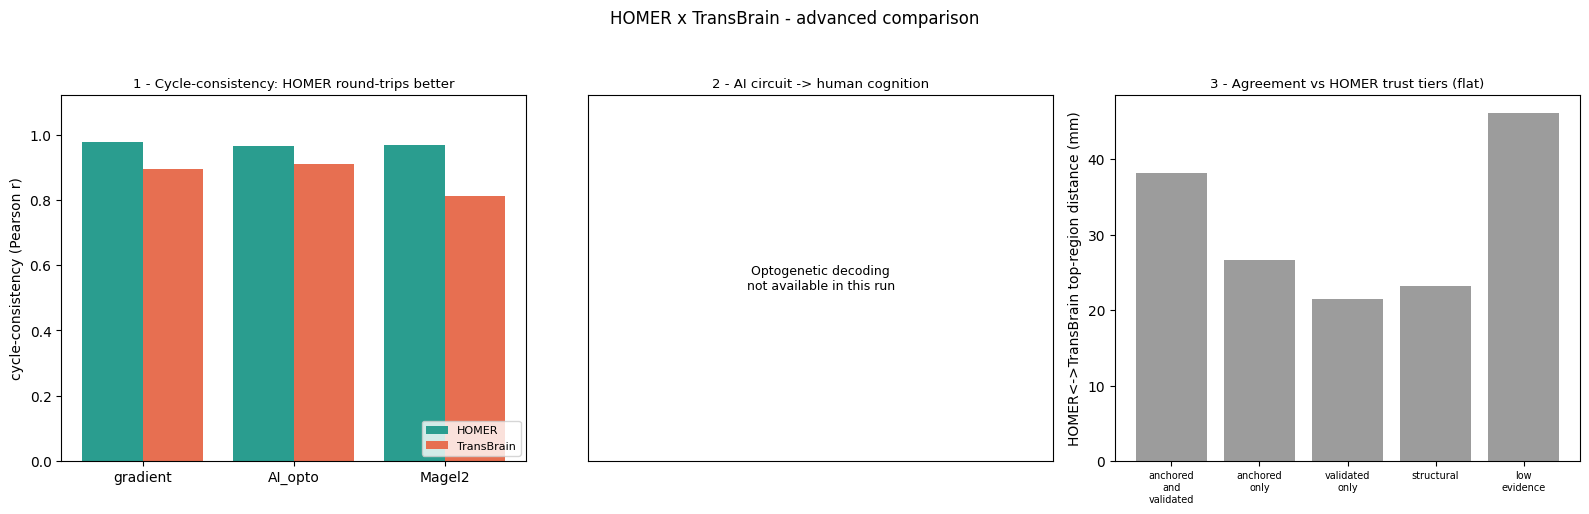

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.9))
cyc = adv['cycle_consistency']; names = list(cyc)
x = np.arange(len(names))
ax = axes[0]
ax.bar(x-0.2, [cyc[n]['homer'] for n in names], 0.4, color='#2a9d8f', label='HOMER')
ax.bar(x+0.2, [cyc[n]['transbrain'] for n in names], 0.4, color='#e76f51', label='TransBrain')
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 1.12)
ax.set_ylabel('cycle-consistency (Pearson r)'); ax.legend(fontsize=8, loc='lower right')
ax.set_title('1 - Cycle-consistency: HOMER round-trips better', fontsize=9.5)

ax = axes[1]
o = adv.get('optogenetic') or {}
if o.get('homer_top10'):
    tb_set = set(o['transbrain_top10'])
    top_h = o['homer_top10']; vals = [o['homer_scores'][t] for t in top_h]
    y = np.arange(len(top_h))[::-1]
    ax.barh(y, vals, color=['#8ab17d' if t in tb_set else '#264653' for t in top_h])
    ax.set_yticks(y); ax.set_yticklabels([t[:22] for t in top_h], fontsize=8)
    ax.set_xlabel('Neurosynth term score (r)')
    ax.set_title('2 - AI circuit -> human cognition\n(green = shared with TransBrain)', fontsize=9.5)
else:
    ax.text(0.5, 0.5, 'Optogenetic decoding\nnot available in this run', ha='center', va='center', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title('2 - AI circuit -> human cognition', fontsize=9.5)

ax = axes[2]
tm = adv['trust_stratified']['tier_mean_topdist_mm']
order = [t for t in ['anchored_and_validated','anchored_only','validated_only','structural','low_evidence'] if t in tm]
ax.bar(range(len(order)), [tm[t] for t in order], color='#9c9c9c')
ax.set_xticks(range(len(order)))
ax.set_xticklabels([t.replace('_','\n') for t in order], fontsize=7)
ax.set_ylabel('HOMER<->TransBrain top-region distance (mm)')
ax.set_title('3 - Agreement vs HOMER trust tiers (flat)', fontsize=9.5)

plt.suptitle('HOMER x TransBrain - advanced comparison', fontsize=12, y=1.04)
plt.tight_layout(); plt.show()

## Interpretation

**HOMER and TransBrain are different tools that agree only moderately** (method-agreement |r| ≈ 0.4). TransBrain, purpose-built and optimised for region-level cross-species phenotype translation, scores higher on region-level head-to-heads, which is its home turf. HOMER's complementary contribution is different in kind: a *soft, parcel-level* coupling π with explicit anchor supervision and per-parcel trust tiers, rather than a region-level point estimate.

Read this experiment as **positioning, not a contest**:

- On TransBrain's literature homology benchmark, a fresh, independent ground truth. HOMER recovers homology at its native region-neighbourhood resolution (centroid ~32 mm from the literature homolog, p < 0.001), consistent with everything HOMER claims about itself; it is not Brainnetome-parcel-precise.
- On head-to-head phenotype translation, the two methods converge moderately on smooth signals and diverge on noisy ones.
- On **bidirectional cycle-consistency**, an even-handed, ground-truth-free metric. HOMER's mouse→human→mouse round-trip is consistently *more* self-consistent (r ≈ 0.97 vs ≈ 0.81–0.91): its soft optimal-transport coupling is internally coherent in both directions.
- Their disagreement is *not* explained by HOMER's trust tiers. HOMER's confidence reflects its own anchor evidence, not inter-method consensus.
- The two frameworks are best seen as complementary entries in the cross-species translation landscape.

This is the eleventh independent comparison in HOMER's validation suite, and the one that places it relative to a contemporary competitor. For full details: [`docs/03_results.md`](../docs/03_results.md) and [`experiments/transbrain_2025_benchmark/`](../experiments/transbrain_2025_benchmark/).